# Clustering

Clustering is an unsupervised machine learning technique that groups data points based on similarities. By identifying inherent patterns, it ensures items within a cluster are more alike to each other than to those in other groups. It is widely used for customer segmentation, image compression, and pattern recognition.

In [25]:
# 1. Load the data
df = pd.read_csv('Mall_Customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [26]:
# 2. Try different numbers of groups (from 1 to 10)
inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_) # Inertia measures how "messy" the groups are

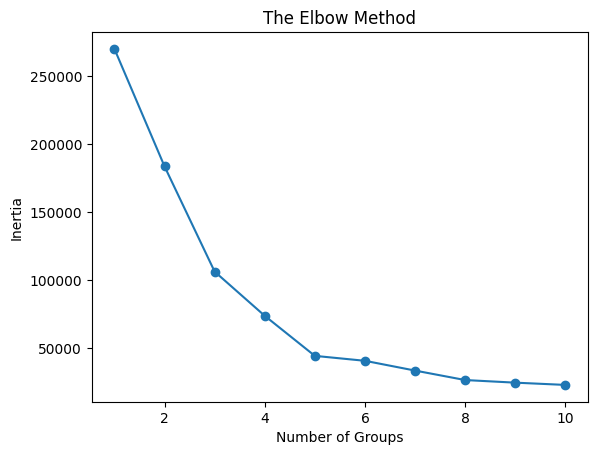

In [27]:
# 3. Plot the results
plt.plot(range(1, 11), inertia, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Groups')
plt.ylabel('Inertia')
plt.show()

WCSS (Within-Cluster Sum of Squares) measures how tightly packed data points are within their clusters. Lower WCSS indicates that points are closer to their respective centroids, signifying better-defined groups.

The Elbow Method is used to find the optimal number of clusters ($K$). By plotting WCSS against different $K$ values, you look for a "kink" or "elbow" in the graph. This point represents the balance where adding more clusters provides diminishing returns in data organization.

### K-Means Clustering

K-Means is a popular unsupervised algorithm that partitions data into K distinct clusters. It iteratively assigns points to the nearest centroid and updates centers until groups represent clear, localized patterns.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

Load the dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
# Select the independent variables

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

Apply K-Means

In [10]:
# Select the number of clusters to be 5.
# To take 5 random mean values and optimize them iteratively.

model = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = model.fit_predict(X)

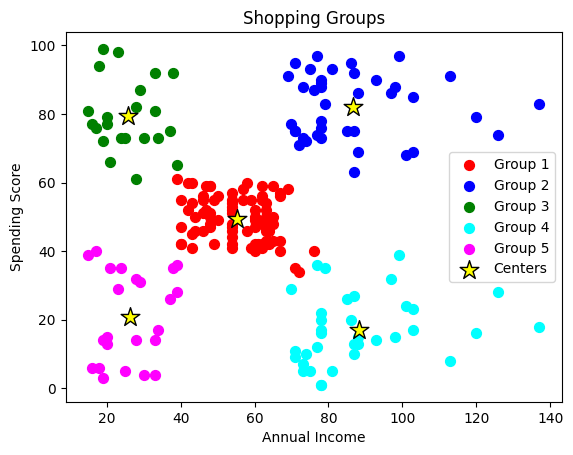

In [11]:
plt.scatter(X.iloc[clusters == 0, 0], X.iloc[clusters == 0, 1], s=50, c='red', label='Group 1')
plt.scatter(X.iloc[clusters == 1, 0], X.iloc[clusters == 1, 1], s=50, c='blue', label='Group 2')
plt.scatter(X.iloc[clusters == 2, 0], X.iloc[clusters == 2, 1], s=50, c='green', label='Group 3')
plt.scatter(X.iloc[clusters == 3, 0], X.iloc[clusters == 3, 1], s=50, c='cyan', label='Group 4')
plt.scatter(X.iloc[clusters == 4, 0], X.iloc[clusters == 4, 1], s=50, c='magenta', label='Group 5')

plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
            s=200, c='yellow', marker='*', edgecolors='black', label='Centers')

plt.title('Shopping Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

Apply K-Medoids

K-Medoid is a robust clustering algorithm that selects actual data points (medoids) as group centers. Unlike K-Means, it minimizes absolute distances, making it highly resistant to noise and outliers.

In [14]:
!pip install -q scikit-learn-extra

In [22]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [20]:
import numpy as np

def perform_kmedoids(data, k, max_iterations=50):
    """A simple K-Medoids implementation for school kids to understand!"""
    # 1. Pick k random real people to start as 'Team Leaders'
    n_samples = data.shape[0]
    np.random.seed(42)
    medoid_indices = np.random.choice(n_samples, k, replace=False)
    medoids = data[medoid_indices]

    for _ in range(max_iterations):
        # 2. Assign every person to the closest Leader
        # We calculate distance between every person and every leader
        distances = np.sqrt(((data[:, np.newaxis, :] - medoids) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=1)

        new_medoid_indices = np.copy(medoid_indices)

        # 3. In each group, see if there's someone better to be the Leader
        for i in range(k):
            cluster_indices = np.where(labels == i)[0]
            if len(cluster_indices) == 0: continue

            # Calculate total distance from every person in the group to everyone else
            cluster_points = data[cluster_indices]
            # Sum of distances for each point in the group
            dist_matrix = np.sqrt(((cluster_points[:, np.newaxis, :] - cluster_points) ** 2).sum(axis=2))
            total_dist = dist_matrix.sum(axis=1)

            # The person with the smallest total distance becomes the new Leader
            best_person_local_idx = np.argmin(total_dist)
            new_medoid_indices[i] = cluster_indices[best_person_local_idx]

        # If the leaders didn't change, we are finished!
        if np.array_equal(new_medoid_indices, medoid_indices):
            break
        medoid_indices = new_medoid_indices
        medoids = data[medoid_indices]

    return labels, medoids

In [23]:
labels, centers = perform_kmedoids(X, 5)

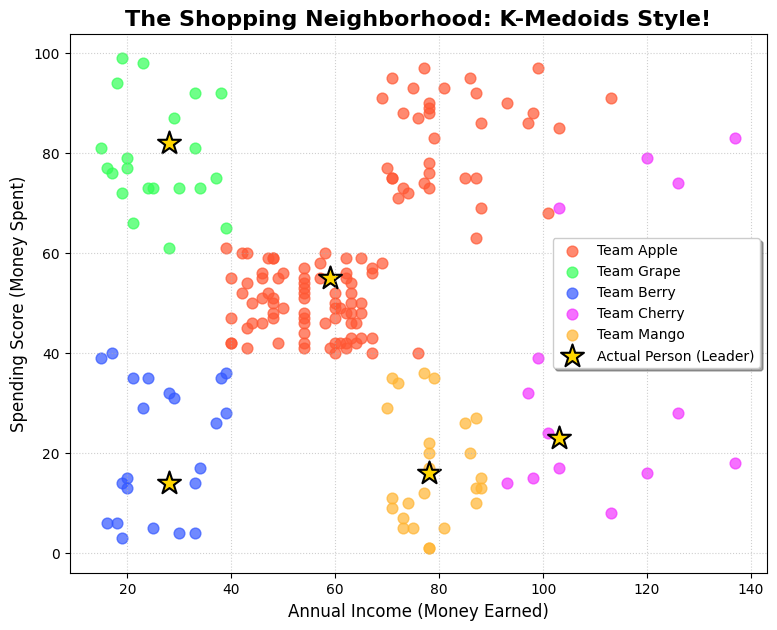

In [24]:
plt.figure(figsize=(9, 7))
colors = ['#FF5733', '#33FF57', '#3357FF', '#F333FF', '#FFB533']
group_names = ['Team Apple', 'Team Grape', 'Team Berry', 'Team Cherry', 'Team Mango']

for i in range(5):
    plt.scatter(X[labels == i, 0], X[labels == i, 1], s=60, c=colors[i], label=group_names[i], alpha=0.7)

# Highlight the Medoids (the "Real Person" leaders)
plt.scatter(centers[:, 0], centers[:, 1], s=300, c='gold', marker='*', edgecolors='black', linewidth=1.5, label='Actual Person (Leader)')

plt.title('The Shopping Neighborhood: K-Medoids Style!', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (Money Earned)', fontsize=12)
plt.ylabel('Spending Score (Money Spent)', fontsize=12)
plt.legend(frameon=True, facecolor='white', shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig('k_medoids_fixed.png')
plt.show()

Hierarchical Clustering

Hierarchical Clustering is a method that builds a "nested" tree of clusters by either merging small groups into larger ones or splitting a large group into smaller pieces.

The Two Main Ways to Build the Tree
Agglomerative (Bottom-Up): Every data point starts as its own tiny cluster. The algorithm then finds the two closest points and links them together, repeating this until everyone belongs to one giant group.

Divisive (Top-Down): Everyone starts in one big group, and the algorithm repeatedly splits the most "different" members away until everyone is alone.

In [28]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [30]:
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

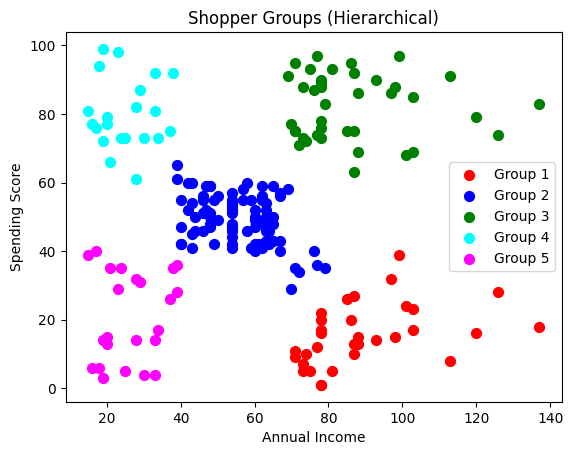

In [31]:
# Plot the shoppers in their new hierarchical groups
plt.scatter(X.values[y_hc == 0, 0], X.values[y_hc == 0, 1], s=50, c='red', label='Group 1')
plt.scatter(X.values[y_hc == 1, 0], X.values[y_hc == 1, 1], s=50, c='blue', label='Group 2')
plt.scatter(X.values[y_hc == 2, 0], X.values[y_hc == 2, 1], s=50, c='green', label='Group 3')
plt.scatter(X.values[y_hc == 3, 0], X.values[y_hc == 3, 1], s=50, c='cyan', label='Group 4')
plt.scatter(X.values[y_hc == 4, 0], X.values[y_hc == 4, 1], s=50, c='magenta', label='Group 5')

plt.title('Shopper Groups (Hierarchical)')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

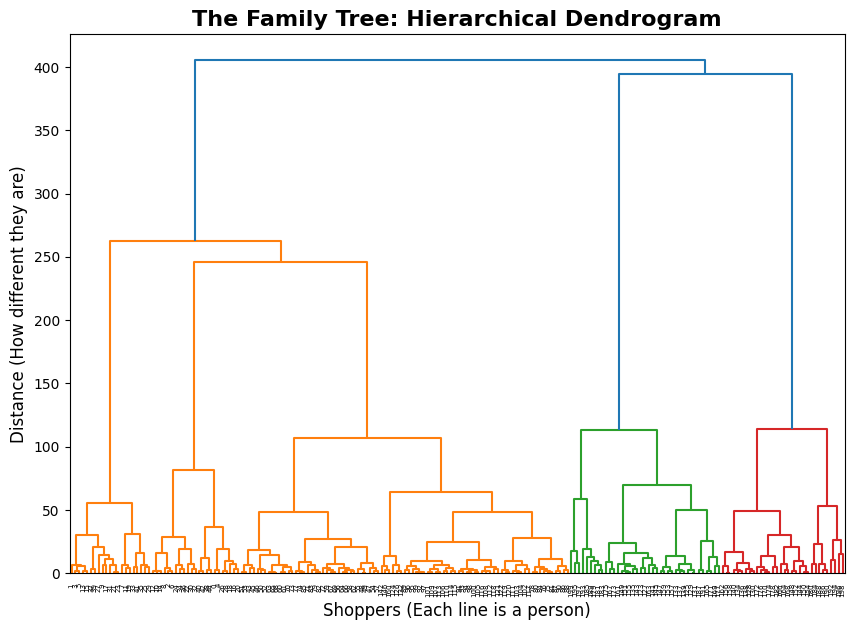

In [32]:
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))

plt.title('The Family Tree: Hierarchical Dendrogram', fontsize=16, fontweight='bold')
plt.xlabel('Shoppers (Each line is a person)', fontsize=12)
plt.ylabel('Distance (How different they are)', fontsize=12)
plt.savefig('dendrogram.png')
plt.show()

Density Based Clustering

Density-Based Clustering identifies groups by looking for regions where data points are "crowded" together, separated by areas of empty space or noise. Unlike other methods, it can discover clusters of any shape and automatically identifies outliers as points that don't belong to any dense neighborhood

In [33]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [34]:
X_scaled = StandardScaler().fit_transform(X)

In [35]:
# 3. Find the crowds!
# eps = How close people need to be to be "neighbors"
# min_samples = How many people make a "crowd"
dbscan = DBSCAN(eps=0.35, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

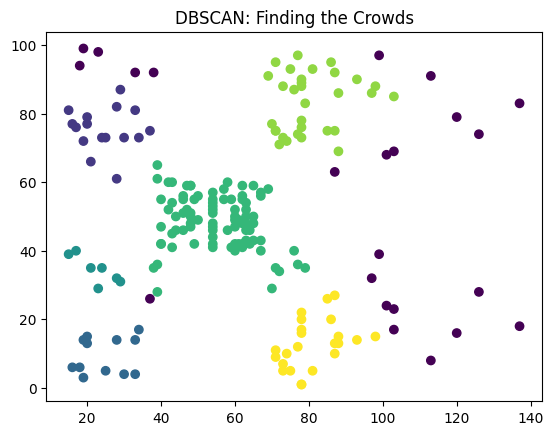

In [36]:
# 4. Plot the results
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters, cmap='viridis')
plt.title('DBSCAN: Finding the Crowds')
plt.show()